# Diamonds Dataset — Exploratory Overview

Load `diamonds.csv` and inspect its shape, dtypes, missing values, and summary statistics.

In [1]:
import pandas as pd

# First column is an unnamed row index, so use it as the DataFrame index
df = pd.read_csv("diamonds.csv", index_col=0)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Shape

In [2]:
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.shape

Rows: 53,940  |  Columns: 10


(53940, 10)

## Data types (dtypes)

In [3]:
df.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

## Missing values per column

In [4]:
missing = df.isna().sum()
print(f"Total missing values: {missing.sum()}")
missing

Total missing values: 0


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

## Summary statistics — describe()

In [5]:
# Numeric columns
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
# Include categorical columns (cut, color, clarity) as well
df.describe(include="all")

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


## Pairplot — raw numeric features

A quick visual overview of the **initial table**: pairwise scatter of all numeric columns, histograms on the diagonal. (Categorical `cut`/`color`/`clarity` are skipped — pairplot only plots numeric columns.)

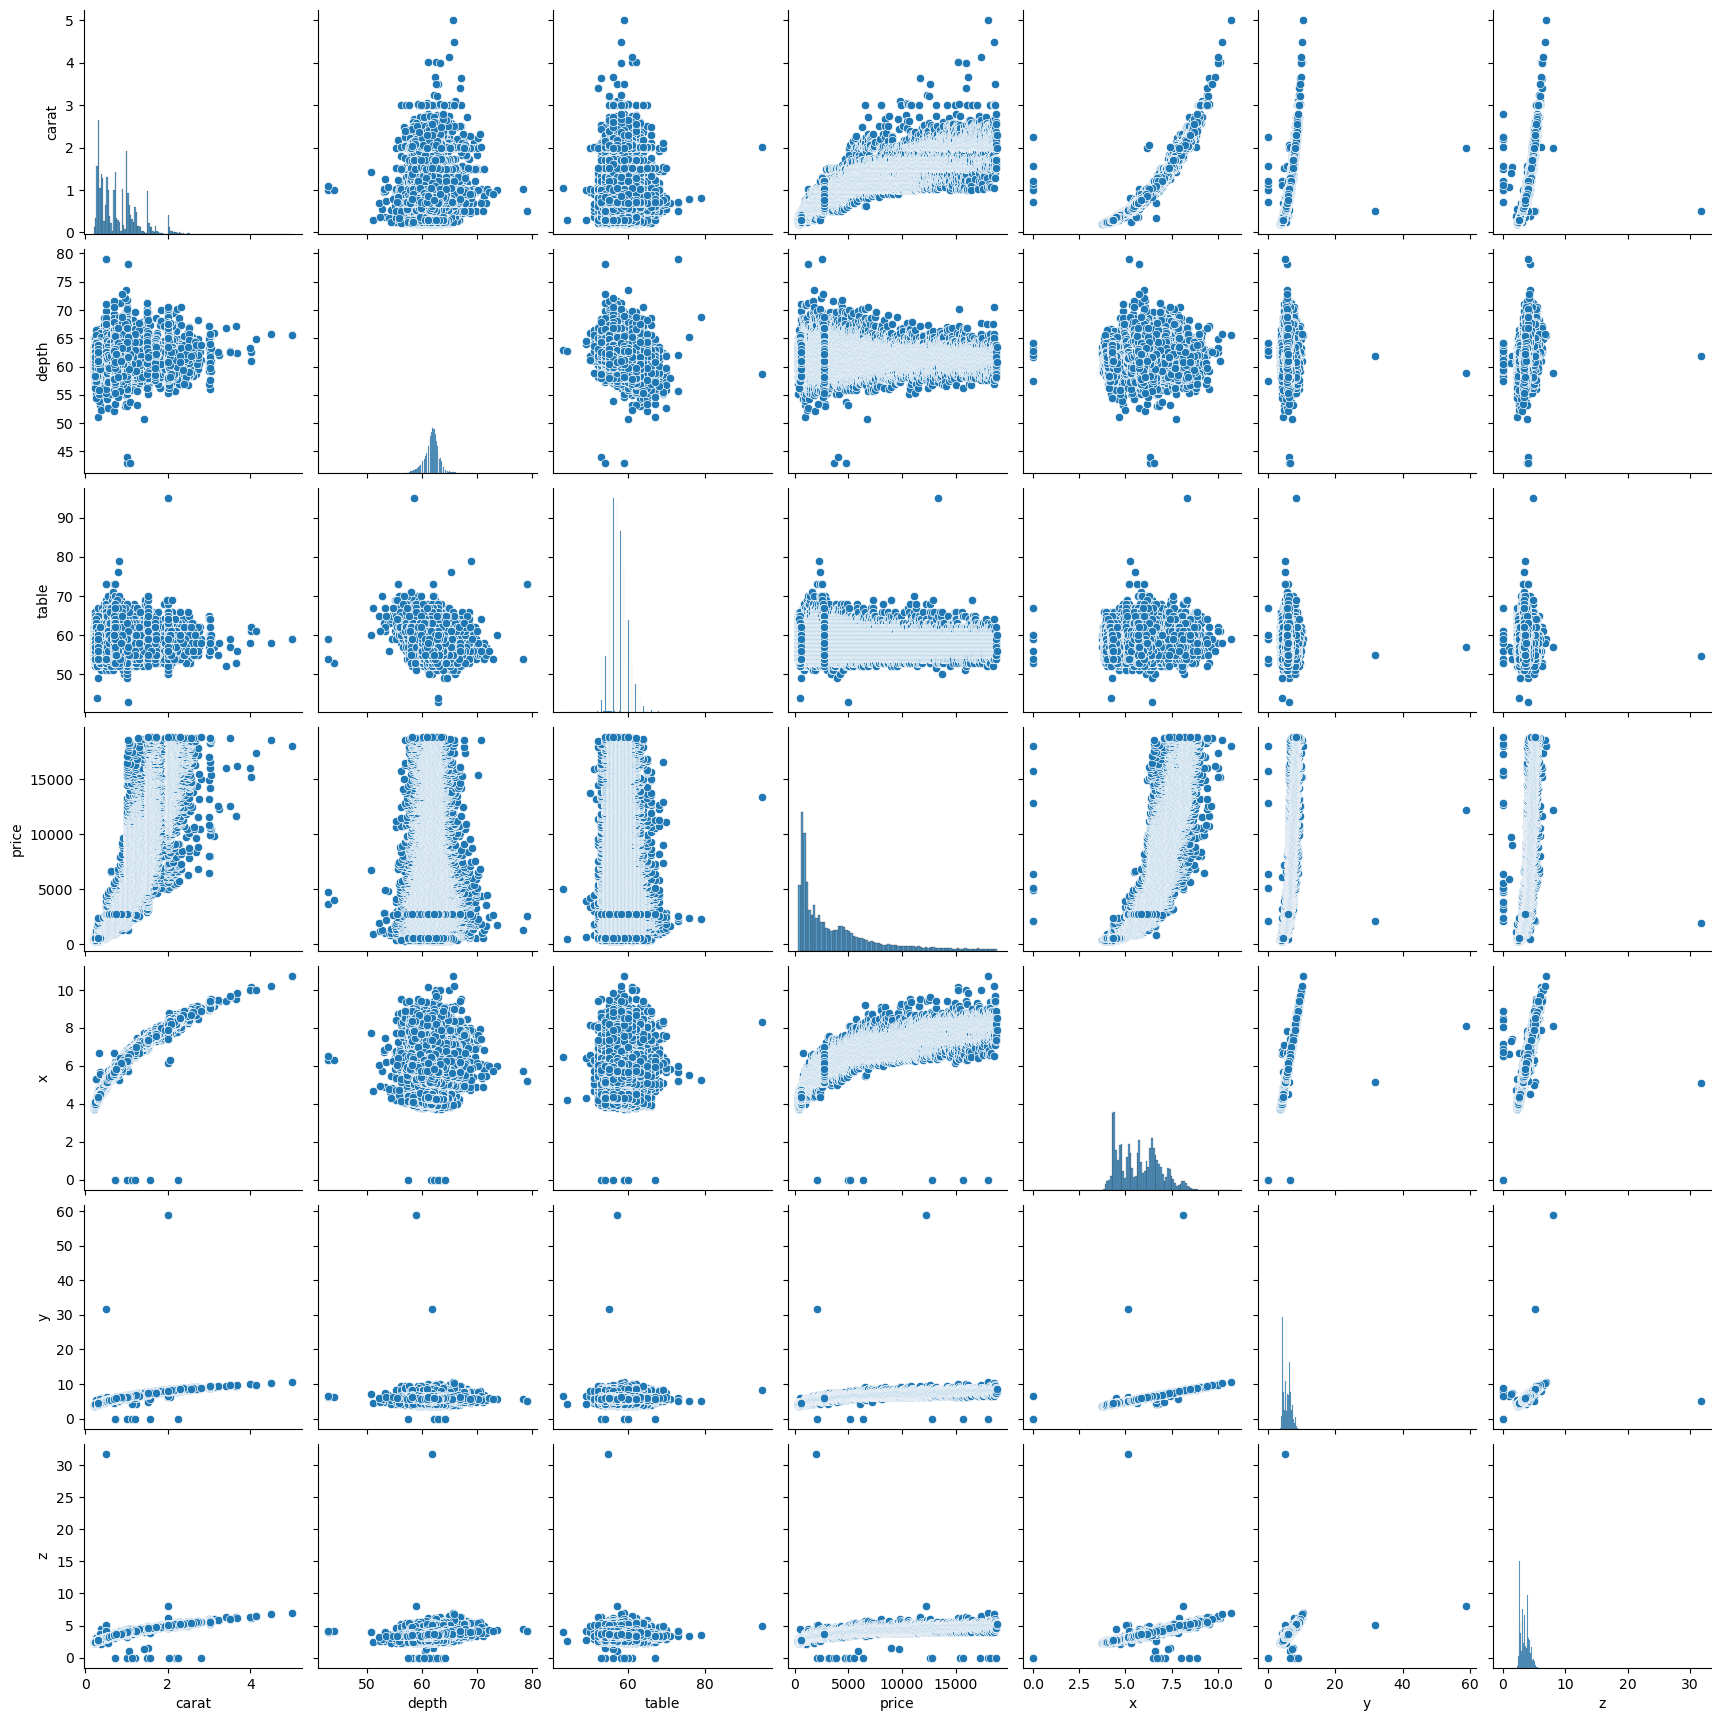

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairwise scatter of every numeric column in the raw table (the 3 categorical
# columns are ignored automatically). Full data (53,940 rows) renders in a few
# seconds here; in Jupyter's inline backend give it ~10-30s before it appears.
sns.pairplot(df)
plt.show()

## Distribution of the target — price

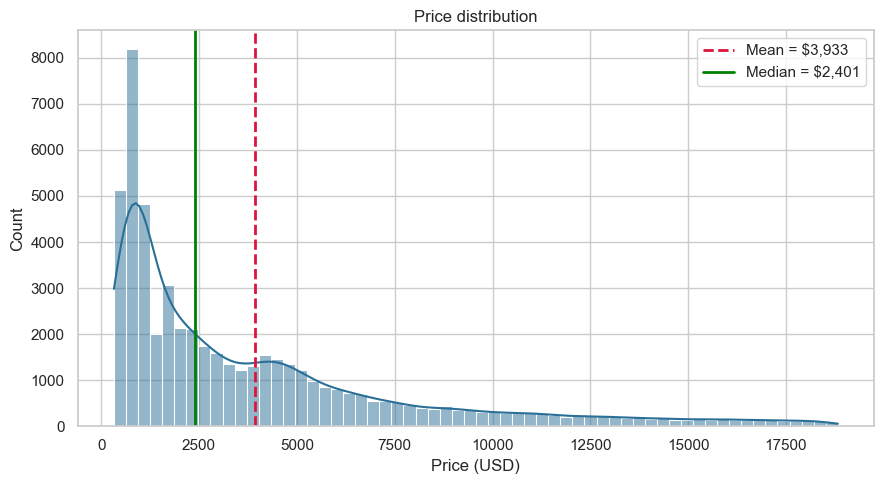

Skewness: 1.62   Median: $2,401   Mean: $3,933


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

price_mean = df["price"].mean()
price_median = df["price"].median()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["price"], bins=60, kde=True, color="#2a6f97", ax=ax)

# Visible mean & median reference lines
ax.axvline(price_mean,   color="crimson", linestyle="--", linewidth=2,
           label=f"Mean = ${price_mean:,.0f}")
ax.axvline(price_median, color="green",   linestyle="-",  linewidth=2,
           label=f"Median = ${price_median:,.0f}")

ax.set_title("Price distribution")
ax.set_xlabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Skewness: {df['price'].skew():.2f}   Median: ${price_median:,.0f}   Mean: ${price_mean:,.0f}")

## Carat distribution

Before deciding whether to log-transform `carat`, check its own shape: is it right-skewed like `price`?

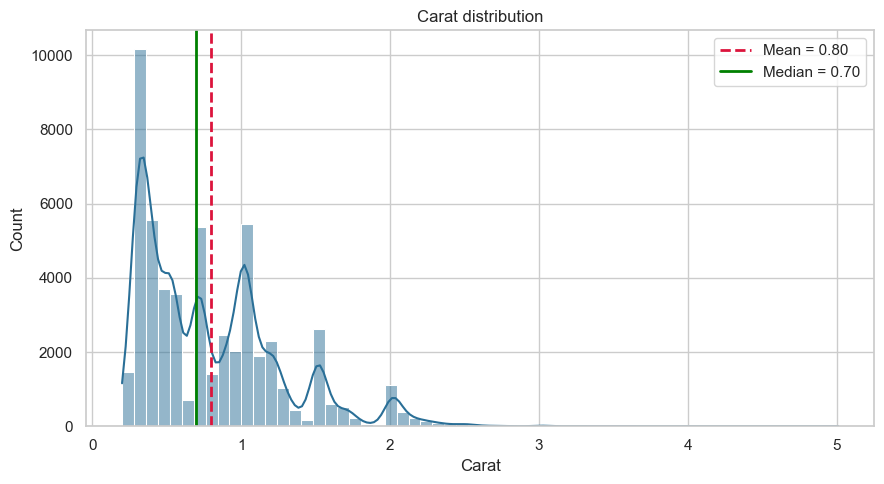

Skewness: 1.12   Median: 0.70   Mean: 0.80


In [11]:
carat_mean = df["carat"].mean()
carat_median = df["carat"].median()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["carat"], bins=60, kde=True, color="#2a6f97", ax=ax)

ax.axvline(carat_mean,   color="crimson", linestyle="--", linewidth=2,
           label=f"Mean = {carat_mean:.2f}")
ax.axvline(carat_median, color="green",   linestyle="-",  linewidth=2,
           label=f"Median = {carat_median:.2f}")

ax.set_title("Carat distribution")
ax.set_xlabel("Carat")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Skewness: {df['carat'].skew():.2f}   Median: {carat_median:.2f}   Mean: {carat_mean:.2f}")

## Price vs carat

`carat` is the strongest predictor of `price`. The scatter shows the relationship curving upward — price grows faster than carat — which is exactly why a log transform helps later.

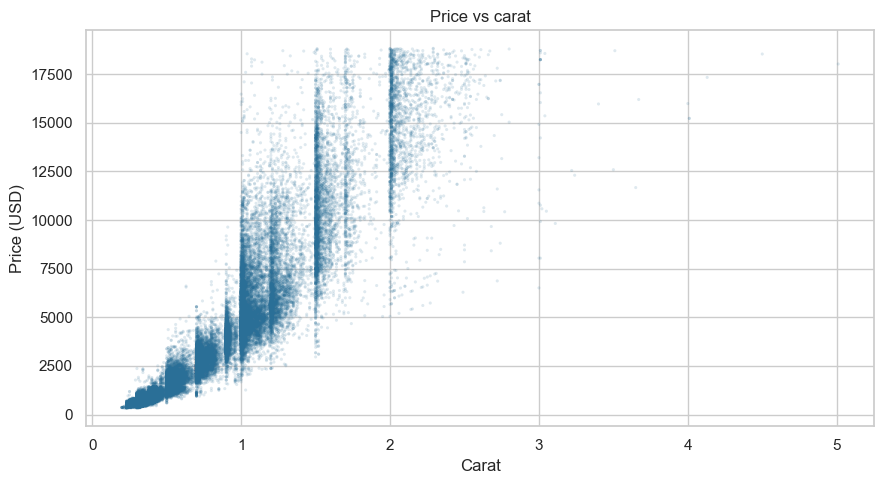

Pearson correlation (carat, price): 0.922


In [10]:
# Scatter of the target against its strongest predictor.
# 53,940 points overlap heavily, so use small markers + transparency.
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["carat"], df["price"], s=5, alpha=0.15, color="#2a6f97", edgecolor="none")

ax.set_title("Price vs carat")
ax.set_xlabel("Carat")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

print(f"Pearson correlation (carat, price): {df['carat'].corr(df['price']):.3f}")

## log–log: price vs carat

Logging **both** `price` and `carat` should turn the curved cloud into a straight line — and it does. A straight **log–log** relationship is the fingerprint of a **power law**, `price = C · caratᵏ`, where the slope of the line is the exponent `k`. (An *exponential* relationship would instead straighten under a semi-log — `log(price)` vs **raw** `carat` — which it does not. See the chat discussion.)

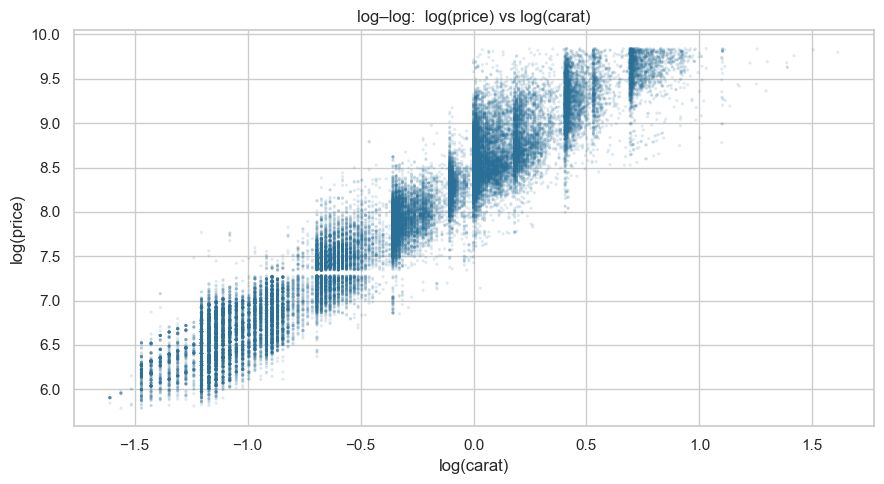

Straight-line fit:  log(price) = 8.45 + 1.68 * log(carat)   (R^2 = 0.933)
=> power law:  price ~ 4669 * carat^1.68


In [12]:
import numpy as np

log_carat = np.log(df["carat"])
log_price = np.log(df["price"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(log_carat, log_price, s=5, alpha=0.15, color="#2a6f97", edgecolor="none")
ax.set_title("log–log:  log(price) vs log(carat)")
ax.set_xlabel("log(carat)")
ax.set_ylabel("log(price)")
plt.tight_layout()
plt.show()

# Fit a straight line. Its slope is the power-law exponent k in  price = C * carat**k
k, c = np.polyfit(log_carat, log_price, 1)
pred = k * log_carat + c
r2 = 1 - ((log_price - pred) ** 2).sum() / ((log_price - log_price.mean()) ** 2).sum()
print(f"Straight-line fit:  log(price) = {c:.2f} + {k:.2f} * log(carat)   (R^2 = {r2:.3f})")
print(f"=> power law:  price ~ {np.exp(c):.0f} * carat^{k:.2f}")

## Correlation heatmap (numeric features)

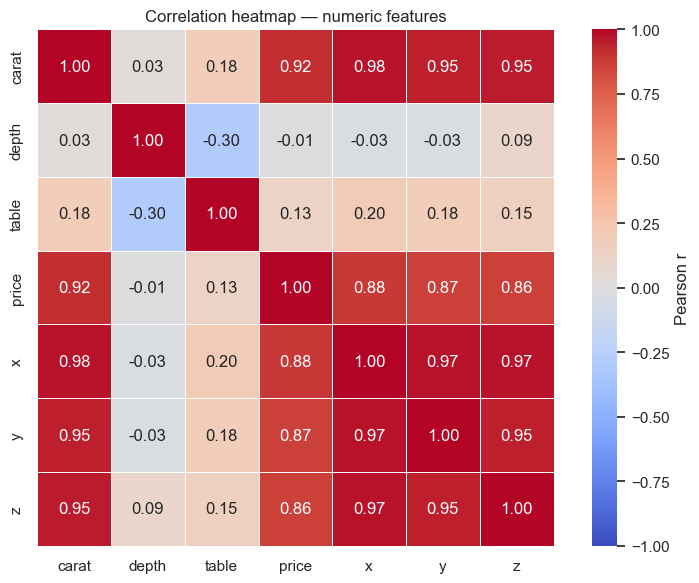

carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64


In [13]:
# Correlation among numeric features (carat, depth, table, price, x, y, z)
numeric = df.select_dtypes(include="number")
corr = numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"})
plt.title("Correlation heatmap — numeric features")
plt.tight_layout()
plt.show()

# Strongest correlations with the target price
print(corr["price"].drop("price").sort_values(ascending=False))

## Step 1 — Encode categorical features

`cut`, `color`, and `clarity` are **ordinal** quality grades, so we map each to an ordered integer (higher = better quality). This preserves the quality ranking and keeps the table compact (vs. one-hot). The encoded data lives in a copy, `df_enc`, leaving the original `df` intact for plotting.

In [14]:
# cut, color, clarity are ORDINAL quality grades, so map each to an ordered
# integer (higher = better quality) instead of one-hot encoding.
cut_order     = ["Fair", "Good", "Very Good", "Premium", "Ideal"]         # worst -> best
color_order   = ["J", "I", "H", "G", "F", "E", "D"]                       # worst (J) -> best (D)
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]   # worst -> best

df_enc = df.copy()
df_enc["cut"]     = pd.Categorical(df_enc["cut"],     categories=cut_order,     ordered=True).codes
df_enc["color"]   = pd.Categorical(df_enc["color"],   categories=color_order,   ordered=True).codes
df_enc["clarity"] = pd.Categorical(df_enc["clarity"], categories=clarity_order, ordered=True).codes

# .codes returns -1 for any value outside the category list -> confirm none slipped through
assert (df_enc[["cut", "color", "clarity"]] >= 0).all().all(), "Unmapped category found!"

print("Encoding legend (label -> code):")
for name, order in [("cut", cut_order), ("color", color_order), ("clarity", clarity_order)]:
    print(f"  {name:8s}: " + ", ".join(f"{lbl}={i}" for i, lbl in enumerate(order)))

print("\ndtypes after encoding:")
print(df_enc.dtypes)
df_enc.head()

Encoding legend (label -> code):
  cut     : Fair=0, Good=1, Very Good=2, Premium=3, Ideal=4
  color   : J=0, I=1, H=2, G=3, F=4, E=5, D=6
  clarity : I1=0, SI2=1, SI1=2, VS2=3, VS1=4, VVS2=5, VVS1=6, IF=7

dtypes after encoding:
carat      float64
cut           int8
color         int8
clarity       int8
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
2,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
3,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
4,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
5,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75


## Step 2 — Dummy (one-hot) encoding for the linear model

For **linear regression**, ordinal codes would force an "evenly spaced" assumption (every grade step adds the same amount to price). One-hot encoding avoids that — each grade gets its own coefficient. We drop one level per feature (`drop_first=True`) as the reference to avoid the dummy-variable trap. The result, `df_lin`, is the model-ready table for the linear path; the ordinal `df_enc` from Step 1 stays available for tree models.

In [15]:
# For the LINEAR model, one-hot encode the grades so each level gets its own
# coefficient (no "evenly spaced" assumption that ordinal codes impose).
df_lin = df.copy()

# Impose the natural quality order so the *lowest* grade becomes the dropped reference.
df_lin["cut"]     = pd.Categorical(df_lin["cut"],     categories=cut_order,     ordered=True)
df_lin["color"]   = pd.Categorical(df_lin["color"],   categories=color_order,   ordered=True)
df_lin["clarity"] = pd.Categorical(df_lin["clarity"], categories=clarity_order, ordered=True)

# drop_first=True drops one level per feature (the reference) to avoid the
# dummy-variable trap (perfect collinearity with the intercept).
df_lin = pd.get_dummies(df_lin, columns=["cut", "color", "clarity"],
                        drop_first=True, dtype=int)

dummy_cols = [c for c in df_lin.columns if c.startswith(("cut_", "color_", "clarity_"))]
print(f"Shape: {df.shape} (original)  ->  {df_lin.shape} (with dummies)")
print(f"\n{len(dummy_cols)} dummy columns created "
      f"(references dropped: cut=Fair, color=J, clarity=I1):")
print(dummy_cols)
df_lin.head()

Shape: (53940, 10) (original)  ->  (53940, 24) (with dummies)

17 dummy columns created (references dropped: cut=Fair, color=J, clarity=I1):
['cut_Good', 'cut_Very Good', 'cut_Premium', 'cut_Ideal', 'color_I', 'color_H', 'color_G', 'color_F', 'color_E', 'color_D', 'clarity_SI2', 'clarity_SI1', 'clarity_VS2', 'clarity_VS1', 'clarity_VVS2', 'clarity_VVS1', 'clarity_IF']


,carat,depth,table,price,x,y,z,cut_Good,cut_Very Good,cut_Premium,...,color_F,color_E,color_D,clarity_SI2,clarity_SI1,clarity_VS2,clarity_VS1,clarity_VVS2,clarity_VVS1,clarity_IF
1,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,0,...,0,1,0,1,0,0,0,0,0,0
2,0.21,59.8,61.0,326,3.89,3.84,2.31,0,0,1,...,0,1,0,0,1,0,0,0,0,0
3,0.23,56.9,65.0,327,4.05,4.07,2.31,1,0,0,...,0,1,0,0,0,0,1,0,0,0
4,0.29,62.4,58.0,334,4.20,4.23,2.63,0,0,1,...,0,0,0,0,0,1,0,0,0,0
5,0.31,63.3,58.0,335,4.34,4.35,2.75,1,0,0,...,0,0,0,1,0,0,0,0,0,0


## Step 3 — Pre-split data checks

Before splitting into train/test, sanity-check the data: **(1)** which features are most correlated with the target (and scatter them), and **(2)** flag any skew, outliers, or non-random missing data that could distort the model.

### 1. Top 3 features most correlated with price

Correlation with price (|r| descending):
carat      0.922
x          0.884
y          0.865
z          0.861
color     -0.173
clarity   -0.147
table      0.127
cut       -0.053
depth     -0.011

Top 3 features: ['carat', 'x', 'y']


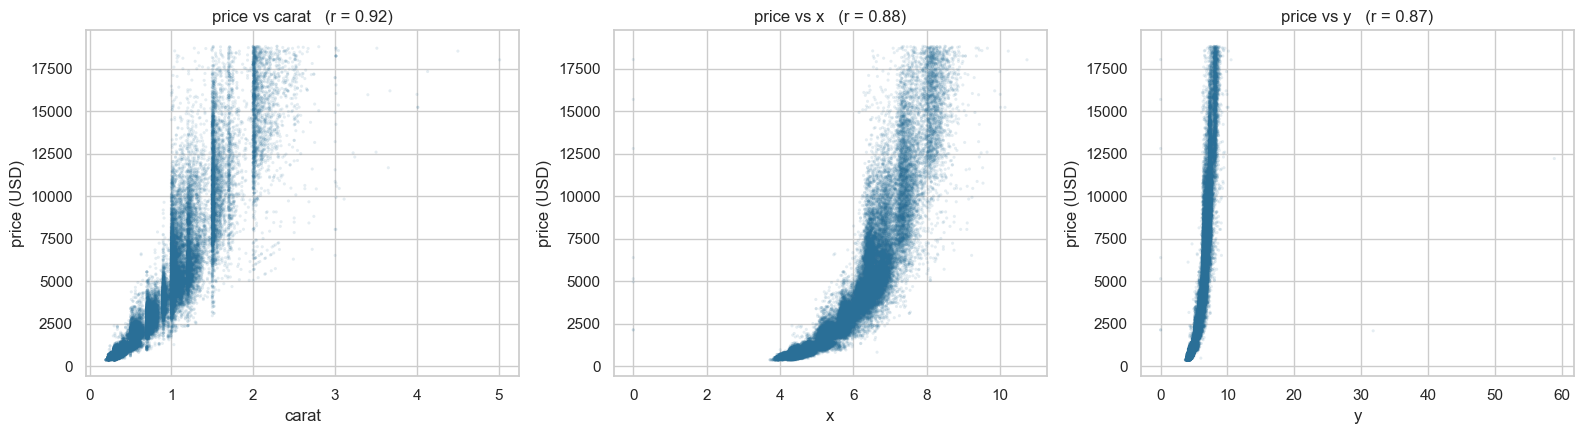

In [16]:
# Rank every feature by |correlation| with price.
# Use the ordinal-encoded df_enc so each categorical is a single number.
corr_with_price = df_enc.corr()["price"].drop("price")
ranked = corr_with_price.reindex(corr_with_price.abs().sort_values(ascending=False).index)
print("Correlation with price (|r| descending):")
print(ranked.round(3).to_string())

top3 = ranked.index[:3].tolist()
print(f"\nTop 3 features: {top3}")

# Scatter each of the top 3 against price
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feat in zip(axes, top3):
    ax.scatter(df[feat], df["price"], s=5, alpha=0.12, color="#2a6f97", edgecolor="none")
    ax.set_title(f"price vs {feat}   (r = {corr_with_price[feat]:.2f})")
    ax.set_xlabel(feat)
    ax.set_ylabel("price (USD)")
plt.tight_layout()
plt.show()

### 2. Skew, outliers, and (disguised) missing data

In [17]:
# --- Skew (|skew| > 1 = strongly skewed) ---
print("Skew (numeric features):")
print(df.select_dtypes("number").skew().sort_values(ascending=False).round(2).to_string())

# --- Disguised missing: physical dimensions recorded as 0 mm (impossible) ---
zero_dim = df[(df.x == 0) | (df.y == 0) | (df.z == 0)]
print(f"\nFormal NaN missing: {df.isna().sum().sum()}")
print(f"Rows with a 0 mm dimension (missing-as-zero): {len(zero_dim)}"
      f"   [x==0: {(df.x==0).sum()}, y==0: {(df.y==0).sum()}, z==0: {(df.z==0).sum()}]")

# --- Extreme dimension outliers (typical x/y/z is ~4-9 mm) ---
print("\nExtreme dimension outliers (y or z > 20 mm):")
print(df[(df.y > 20) | (df.z > 20)][["carat", "price", "x", "y", "z"]].to_string())

Skew (numeric features):
y        2.43
price    1.62
z        1.52
carat    1.12
table    0.80
x        0.38
depth   -0.08

Formal NaN missing: 0
Rows with a 0 mm dimension (missing-as-zero): 20   [x==0: 8, y==0: 7, z==0: 20]

Extreme dimension outliers (y or z > 20 mm):
       carat  price     x      y      z
24068   2.00  12210  8.09  58.90   8.06
48411   0.51   1970  5.12   5.15  31.80
49190   0.51   2075  5.15  31.80   5.12


### What the checks found

**Top-3 correlated features are all size proxies.** `carat` (0.92), `x` (0.88), `y` (0.87) — with `z` (0.86) right behind. They measure the *same thing* (size) and are mutually correlated > 0.97, so keeping all of them in a linear model causes **multicollinearity** (unstable coefficients). Plan: keep `carat` and drop / combine the raw dimensions.

**Quality grades correlate slightly *negatively* with price** (color −0.17, clarity −0.15). Counter-intuitive but real: bigger stones dominate price and tend to be lower color/clarity, so the *raw* correlation flips. Their true effect appears only after controlling for size — which is why we still keep them as features.

**Skew:** `price` (1.62) and `carat` (1.12) are genuinely right-skewed → handled by the planned `log`. `y` (2.43) and `z` (1.52) look skewed too, but that is **fake skew from outliers** (below), not a real heavy tail.

**Outliers = data-entry errors, not real diamonds:** `y = 58.9` on a stone with x≈8.1, z≈8.1; `y = 31.8` and `z = 31.8` on 0.5-ct stones whose other dimensions are ≈5.1. Physically impossible — digit errors. They inflate the y/z skew and would distort a linear fit → drop or correct.

**"Missing" data is disguised and non-random:** `isna()` reports **0** missing, but **20 rows have a dimension recorded as 0 mm** (impossible for a real diamond) — missing-encoded-as-zero. It is **not random**: all 20 have `z = 0` (only 8 have x=0, 7 y=0), so *depth specifically* failed to record, and those rows skew toward larger/pricier stones → treat the zeros as missing and drop/impute.

**Action list before splitting:** (1) drop/fix the ~20 zero-dimension rows + the 2–3 extreme y/z outliers; (2) `log` price & carat; (3) resolve the size-feature collinearity.

## Step 4 — Clean and prepare for the linear model

Apply the Step 3 to-do list, building the model-ready table `df_model` from the one-hot `df_lin`:
**(1)** drop the bad rows, **(2)** log-transform `price` and `carat`, **(3)** resolve the size-feature multicollinearity.

### (1) Drop the bad rows

Drop the 20 zero-dimension rows (missing-as-zero) plus the 3 extreme y/z outliers (impossible dimensions) — 23 rows total, < 0.05% of the data.

In [18]:
df_clean = df_lin.copy()

# Bad rows: impossible 0 mm dimensions (missing-as-zero) + extreme y/z outliers (digit errors)
bad = (df_clean[["x", "y", "z"]] == 0).any(axis=1) | (df_clean["y"] > 20) | (df_clean["z"] > 20)
n_zero = (df_clean[["x", "y", "z"]] == 0).any(axis=1).sum()
n_ext  = ((df_clean["y"] > 20) | (df_clean["z"] > 20)).sum()
print(f"Dropping {bad.sum()} rows  ({n_zero} zero-dimension + {n_ext} extreme outliers)")

df_clean = df_clean[~bad].copy()
print(f"Shape: {df_lin.shape} -> {df_clean.shape}")

Dropping 23 rows  (20 zero-dimension + 3 extreme outliers)
Shape: (53940, 24) -> (53917, 24)


### (2) Log-transform price and carat

Replace the skewed `price` (target) and `carat` with `log_price` and `log_carat`. This de-skews both **and** straightens the power-law relationship into the line a linear model can fit.

In [19]:
df_clean["log_price"] = np.log(df_clean["price"])
df_clean["log_carat"] = np.log(df_clean["carat"])

print("Skew  (raw -> log):")
print(f"  price: {df_clean['price'].skew():6.2f}  ->  {df_clean['log_price'].skew():.2f}")
print(f"  carat: {df_clean['carat'].skew():6.2f}  ->  {df_clean['log_carat'].skew():.2f}")

Skew  (raw -> log):
  price:   1.62  ->  0.12
  carat:   1.12  ->  0.10


### (3) Resolve size multicollinearity

`carat`, `x`, `y`, `z` all measure the same thing — size — and are almost perfectly correlated (~0.98+). A linear model can't separate their effects, giving unstable, uninterpretable coefficients. First confirm it with their correlation matrix, then keep only `carat` (as `log_carat`) and drop the raw dimensions.

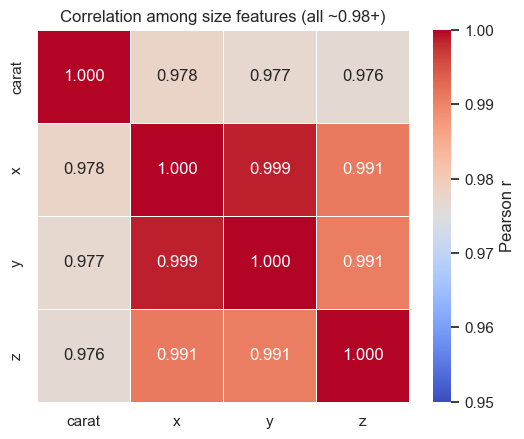

Final model table df_model: (53917, 21)
['depth', 'table', 'cut_Good', 'cut_Very Good', 'cut_Premium', 'cut_Ideal', 'color_I', 'color_H', 'color_G', 'color_F', 'color_E', 'color_D', 'clarity_SI2', 'clarity_SI1', 'clarity_VS2', 'clarity_VS1', 'clarity_VVS2', 'clarity_VVS1', 'clarity_IF', 'log_price', 'log_carat']


In [20]:
size = ["carat", "x", "y", "z"]
size_corr = df_clean[size].corr()

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(size_corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=0.95, vmax=1.0,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"})
plt.title("Correlation among size features (all ~0.98+)")
plt.tight_layout()
plt.show()

# Drop the redundant size columns (keep carat, now represented by log_carat).
# Also drop the raw price/carat that the log columns replace.
df_model = df_clean.drop(columns=["x", "y", "z", "carat", "price"])
print(f"Final model table df_model: {df_model.shape}")
print(list(df_model.columns))

### Result — `df_model`

The cleaned, model-ready table for the linear path:
- **53,917 rows** (23 bad rows removed)
- **Target:** `log_price`
- **Features:** `log_carat`, `depth`, `table`, and the 17 grade dummies
- Target and main feature skew now ≈ 0; the four size columns collapsed into a single `log_carat`.

Ready for the train/test split.

## Step 5 — Train/test split, pipeline, and evaluation

Split `df_model` 80/20 (`test_size=0.2`, `random_state=42` for reproducibility), fit a `SimpleImputer(median) → StandardScaler → LinearRegression` pipeline on **train only**, and evaluate on the **held-out test set**.

A few notes:
- The pipeline predicts `log_price`, so the metrics are in **log space**; we also back-transform to dollars for intuition.
- `SimpleImputer` is effectively a no-op here (we already removed the bad rows) but is kept for good pipeline hygiene / robustness to future data.
- `StandardScaler` doesn't change OLS predictions or R², but standardizes the features (and becomes important once we add regularization).

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features (X) and target (y)
X = df_model.drop(columns="log_price")
y = df_model["log_price"]

# 80 / 20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]:,} rows    Test: {X_test.shape[0]:,} rows    Features: {X.shape[1]}")

# Pipeline: impute (median) -> standardize -> linear regression
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LinearRegression()),
])
pipe.fit(X_train, y_train)   # fit on TRAIN only
print("Pipeline fitted on training data.")

Train: 43,133 rows    Test: 10,784 rows    Features: 20
Pipeline fitted on training data.


### Test-set metrics (evaluated on the held-out test set only)

In [22]:
y_pred = pipe.predict(X_test)   # predictions on the held-out TEST set only

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("TEST-SET metrics (log-price space):")
print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R^2  : {r2:.4f}")

# Back-transform to dollars for intuition (approximate: ignores retransformation bias)
price_true, price_pred = np.exp(y_test), np.exp(y_pred)
print("\nApprox. dollar-space error:")
print(f"  MAE  : ${mean_absolute_error(price_true, price_pred):,.0f}")
print(f"  RMSE : ${np.sqrt(mean_squared_error(price_true, price_pred)):,.0f}")

TEST-SET metrics (log-price space):
  MAE  : 0.1036
  MSE  : 0.0178
  RMSE : 0.1335
  R^2  : 0.9826

Approx. dollar-space error:
  MAE  : $397
  RMSE : $771


### Predicted vs actual, and residuals

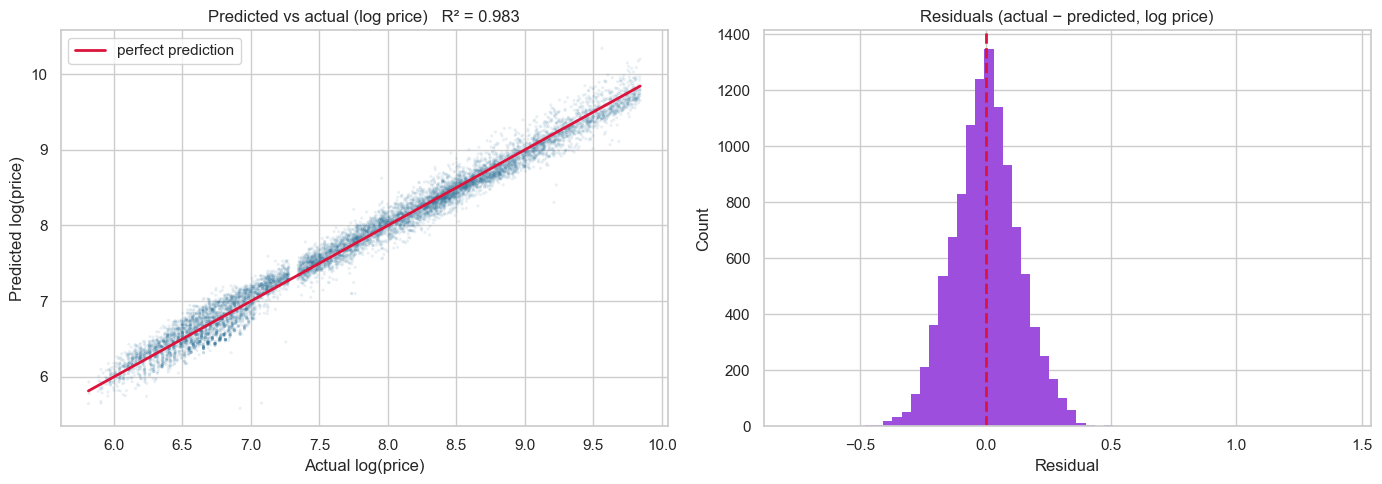

Residuals: mean = 0.0012  (≈ 0 => unbiased),  std = 0.1335


In [23]:
y_pred = pipe.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual (log price)
axes[0].scatter(y_test, y_pred, s=5, alpha=0.10, color="#2a6f97", edgecolor="none")
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, color="crimson", linewidth=2, label="perfect prediction")
axes[0].set_title(f"Predicted vs actual (log price)   R² = {r2:.3f}")
axes[0].set_xlabel("Actual log(price)")
axes[0].set_ylabel("Predicted log(price)")
axes[0].legend()

# Histogram of residuals
axes[1].hist(residuals, bins=60, color="#9d4edd", edgecolor="none")
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("Residuals (actual − predicted, log price)")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Residuals: mean = {residuals.mean():.4f}  (≈ 0 => unbiased),  std = {residuals.std():.4f}")

### What the results say

- **R² = 0.983** on the **test set** — the linear model explains ~98% of the variance in log-price on data it never saw. The log–log groundwork paid off.
- **RMSE = 0.134 in log units ≈ ±14%** typical error; back-transformed that's **MAE ≈ \$397** and **RMSE ≈ \$771** per stone (RMSE > MAE because a few expensive stones carry larger errors).
- **Predicted vs actual** hugs the diagonal with no systematic bend → the functional form is right.
- **Residuals** are centered on 0 (mean ≈ 0.001 → unbiased) and roughly bell-shaped — exactly what the log transform was meant to deliver. A mild heavy tail remains (a few hard-to-price stones).

A strong linear baseline. Natural next steps: add polynomial/interaction terms, or fit a tree/boosting model on the ordinal `df_enc` to try to beat it.

## Step 6 — Compare models (same train/test split)

Using the **same** split from Step 5, compare a grid of **2 feature sets × 4 estimators**:

- **Feature sets:** plain (20 features) vs **Poly(2)** (`PolynomialFeatures(degree=2)`, 230 features)
- **Estimators:** `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`

That's 8 models. Each is a `SimpleImputer(median) → [PolynomialFeatures] → StandardScaler → estimator` pipeline. We report test **RMSE**, **R²**, **adjusted R²**, and the **number of non-zero coefficients** (to see Lasso/ElasticNet's feature selection), then plot learning curves for the best and worst model.

*Note:* the regularization strength `alpha` is fixed (not CV-tuned) so the cell runs in seconds — CV on the 230 polynomial features takes minutes.

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet

def make(est, poly=False):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if poly:
        steps.append(("poly", PolynomialFeatures(degree=2, include_bias=False)))
    steps += [("scaler", StandardScaler()), ("model", est)]
    return Pipeline(steps)

# Fixed penalty (not CV-tuned) so the cell runs in seconds. A is deliberately
# small-but-not-tiny: large enough that Lasso/ElasticNet converge fast and
# actually zero out features; CV would trade a little less accuracy for sparsity.
A = 0.005
def lasso(): return Lasso(alpha=A, max_iter=2000, tol=1e-3)
def enet():  return ElasticNet(alpha=A, l1_ratio=0.5, max_iter=2000, tol=1e-3)

models = {
    "LinearRegression":     make(LinearRegression()),
    "Ridge":                make(Ridge(alpha=1.0)),
    "Lasso":                make(lasso()),
    "ElasticNet":           make(enet()),
    "Poly(2) + Linear":     make(LinearRegression(), poly=True),
    "Poly(2) + Ridge":      make(Ridge(alpha=1.0),   poly=True),
    "Poly(2) + Lasso":      make(lasso(),            poly=True),
    "Poly(2) + ElasticNet": make(enet(),             poly=True),
}

rows = []
n_test = len(y_test)
for name, p in models.items():
    p.fit(X_train, y_train)               # same training split as Step 5
    pred = p.predict(X_test)             # evaluate on the same held-out test set
    coef = p.named_steps["model"].coef_
    r2 = r2_score(y_test, pred)
    p_feat = coef.shape[0]
    rows.append({
        "Model":      name,
        "Test RMSE":  np.sqrt(mean_squared_error(y_test, pred)),
        "Test R2":    r2,
        # Adjusted R2 penalizes the feature count p:
        "Adj R2":     1 - (1 - r2) * (n_test - 1) / (n_test - p_feat - 1),
        "# features": p_feat,
        "# nonzero":  int((coef != 0).sum()),   # sparsity: Lasso/ElasticNet zero some out
    })

results = pd.DataFrame(rows).set_index("Model").sort_values("Test RMSE")
results.round(4)

,Test RMSE,Test R2,Adj R2,# features,# nonzero
Model,,,,,
Poly(2) + Ridge,0.1214,0.9856,0.9853,230,188
Poly(2) + Linear,0.1214,0.9856,0.9853,230,209
Ridge,0.1335,0.9826,0.9826,20,20
LinearRegression,0.1335,0.9826,0.9826,20,20
Poly(2) + ElasticNet,0.1378,0.9815,0.9811,230,106
ElasticNet,0.1457,0.9793,0.9793,20,18
Poly(2) + Lasso,0.1506,0.9779,0.9774,230,91
Lasso,0.1564,0.9761,0.9761,20,19


### What the comparison shows

- **Polynomial features are the real win.** Every poly model with enough capacity (Linear/Ridge) beats every plain model — RMSE **0.121** vs **0.134**, R² 0.986 vs 0.983. The interaction terms (e.g. `carat × clarity`) genuinely matter.
- **Ridge ≡ Linear** on both feature sets — identical RMSE, all coefficients kept. With 43k rows and few features there's nothing to overfit, so the L2 penalty has nothing to do.
- **Lasso & ElasticNet are sparser but, here, worse.** They zero out features (Poly+Lasso keeps only **91/230**, Poly+ElasticNet **106/230**; plain Lasso/ElasticNet drop 1–2 of 20) — but at the fixed `alpha=0.005` they over-shrink and lose accuracy (RMSE 0.14–0.16). 

**Honest takeaway:** for *this* data (large n, few features, little overfitting) regularization doesn't buy accuracy — Ridge ties plain Linear, and Lasso/ElasticNet trade accuracy for a simpler model. The gain came from the **polynomial features**, not the penalty. Lasso/ElasticNet earn their keep when features are many/noisy or data is scarce — not the case here.

### Learning curves — best vs worst model

To diagnose under/overfitting, plot learning curves (training-set size vs error) for the **best** and **worst** model (chosen automatically by test RMSE).

How to read them:
- **Both curves high and close together** → underfitting (high bias) — the model is too simple.
- **Large gap (train low, validation high)** → overfitting (high variance) — the model memorizes noise.

Best (lowest RMSE):  Poly(2) + Ridge
Worst (highest RMSE): Lasso


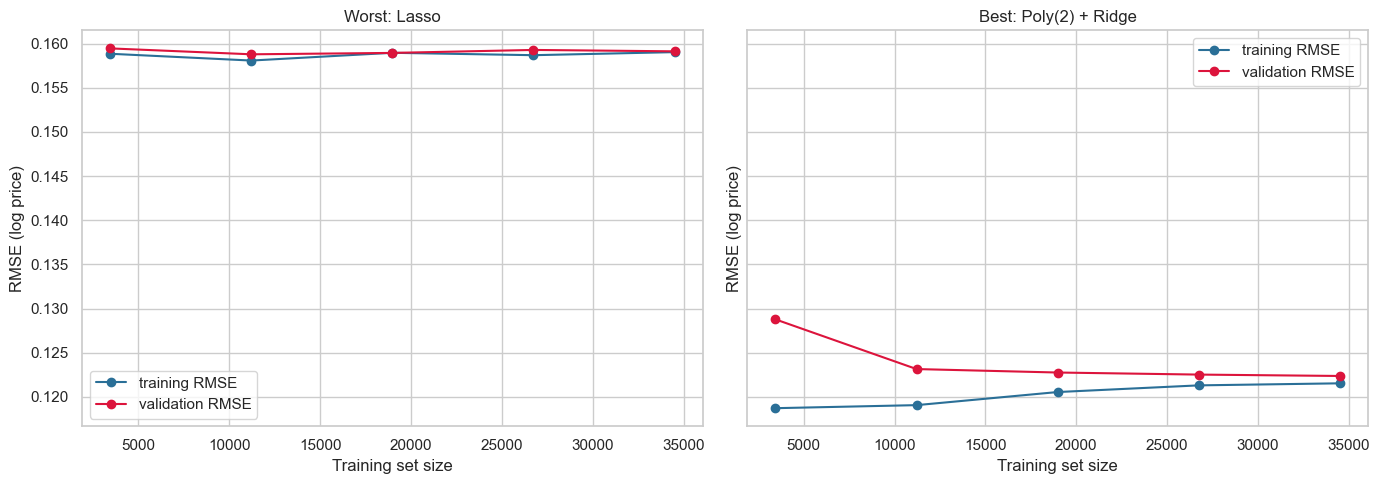

In [25]:
from sklearn.model_selection import learning_curve

# Pick best & worst by test RMSE automatically from the results table
best_name  = results["Test RMSE"].idxmin()
worst_name = results["Test RMSE"].idxmax()
print(f"Best (lowest RMSE):  {best_name}\nWorst (highest RMSE): {worst_name}")
train_sizes = np.linspace(0.1, 1.0, 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (label, name) in zip(axes, [("Worst", worst_name), ("Best", best_name)]):
    # 5-fold CV on the TRAINING data only (test set stays untouched)
    sizes, train_sc, val_sc = learning_curve(
        models[name], X_train, y_train, cv=5, train_sizes=train_sizes,
        scoring="neg_root_mean_squared_error", n_jobs=-1)
    train_rmse, val_rmse = -train_sc.mean(axis=1), -val_sc.mean(axis=1)

    ax.plot(sizes, train_rmse, "o-", color="#2a6f97", label="training RMSE")
    ax.plot(sizes, val_rmse,   "o-", color="crimson",  label="validation RMSE")
    ax.set_title(f"{label}: {name}")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("RMSE (log price)")
    ax.legend()

plt.tight_layout()
plt.show()

### What the learning curves say

Auto-selected **best = Poly(2)+Ridge** (RMSE ~0.121) and **worst = plain Lasso** (RMSE ~0.156).

- **Worst — plain Lasso:** training and validation curves sit **high and glued together** (~0.156). That's high bias — but here it's *over-regularization* (the fixed `alpha` shrinks real signal away), not a too-simple model. More data won't fix a penalty that's too strong.
- **Best — Poly(2)+Ridge:** both curves sit much lower (~0.122) with only a sliver of a gap → it captures real structure (interaction terms) without overfitting.
- **Neither overfits** — nowhere do we see the train-low / validation-high gap that signals high variance. The story here is **bias, not variance**: the worst model is bias-limited by its penalty, the best is well-balanced.

**Bottom line:** the polynomial features give the real, statistically-significant gain (R² 0.983 → 0.986); regularization here only trades accuracy for sparsity.

## Step 6 follow-ups — adjusted R², polynomial degree, and the best model's coefficients

### (1) Adjusted R²

Plain R² can only go **up** when you add features (in-sample), so comparing a 20-feature model to a 230-feature one on R² alone is unfair. **Adjusted R²** fixes that by penalizing the feature count `p`:

$$R^2_{\text{adj}} = 1 - (1 - R^2)\,\frac{n-1}{n-p-1}$$

It's now a column in the Step 6 table above. Two honest caveats:
- We evaluate on a **held-out test set**, where plain R² is *already* honest — useless features don't help out-of-sample — so adjusted R² is partly redundant here.
- Because **n ≈ 10,784 ≫ p**, the penalty is tiny: adjusted R² barely differs from R² (Poly+Ridge 0.9856 → 0.9853). Adjusted R² bites hardest when `p` is large relative to `n` — which is exactly what the high-degree polynomials below reveal.

### (2) Why polynomial degree 2 — and not 3, 4, 5…?

Degree `d` on `n` features creates **all products up to degree d**, which grows combinatorially as $\binom{n+d}{d}$. The cell below fits degrees 1–3 and shows the explosion beyond.

In [26]:
from math import comb

print("Polynomial degree vs feature count and test performance (Ridge):")
print(f"{'degree':>6} {'# features':>12} {'Test RMSE':>10} {'Test R2':>9} {'Adj R2':>9}")
for deg in [1, 2, 3]:
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if deg > 1:
        steps.append(("poly", PolynomialFeatures(degree=deg, include_bias=False)))
    steps += [("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]
    p = Pipeline(steps).fit(X_train, y_train)
    pred = p.predict(X_test)
    nf  = p.named_steps["model"].coef_.shape[0]
    r2  = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    adj = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - nf - 1)
    print(f"{deg:>6} {nf:>12,} {rmse:>10.4f} {r2:>9.5f} {adj:>9.5f}")

print("\nIf we kept going — feature count grows as C(n+d, d):")
for deg in [4, 5, 6, 7]:
    print(f"  degree {deg}: {comb(20 + deg, deg) - 1:>10,} features")

Polynomial degree vs feature count and test performance (Ridge):
degree   # features  Test RMSE   Test R2    Adj R2
     1           20     0.1335   0.98262   0.98259


     2          230     0.1214   0.98563   0.98532


     3        1,770     0.1120   0.98777   0.98537

If we kept going — feature count grows as C(n+d, d):
  degree 4:     10,625 features
  degree 5:     53,129 features
  degree 6:    230,229 features
  degree 7:    888,029 features


**What this shows:**
- **The feature count explodes:** 20 → 230 → 1,770 → 10,625 → 53,129 → 230,229 → 888,029 for degrees 1–7. By **degree 5 you'd have more features than the 43k training rows** (p ≳ n) — guaranteed overfitting and unstable fits; degrees 6–7 are infeasible.
- **Diminishing returns:** degree 3 *does* edge out degree 2 on the test set (RMSE 0.121 → 0.112), but look at **adjusted R²** — it barely moves (0.98532 → 0.98537). The ~1,540 extra features bought almost nothing, exactly the over-fitting tax adjusted R² is built to expose.
- **Most higher terms are dead anyway:** 17 of 20 features are 0/1 dummies, and `dummy^k = dummy`, while products of same-category dummies are always 0 — so higher degrees mostly manufacture redundant/zero columns.

**So degree 2 is the sweet spot:** it captures the useful interactions, stays interpretable, and the log transform already removed the main curvature. Degree 3 is *defensible* for a small gain; beyond that the cost explodes for no real benefit. The principled way to choose is cross-validation — which here would stop at 2–3.

### (3) The best model's coefficients

The best model is **Poly(2)+Ridge** (230 coefficients). Since the features are standardized, **coefficient magnitude = importance** (directly comparable across features). Showing the 15 largest:

In [27]:
best = models["Poly(2) + Ridge"]
feat_names = best.named_steps["poly"].get_feature_names_out(X.columns)
coefs = pd.Series(best.named_steps["model"].coef_, index=feat_names)

# Features are standardized, so coefficient magnitude = importance (directly comparable)
print(f"Best model: Poly(2)+Ridge  ({len(coefs)} coefficients)\n")
print("Top 15 by |coefficient| (standardized features):")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15).round(4).to_string())

Best model: Poly(2)+Ridge  (230 coefficients)

Top 15 by |coefficient| (standardized features):
log_carat                1.1262
depth cut_Premium        0.2625
depth log_carat         -0.2429
depth table              0.1479
depth clarity_VS2        0.1346
depth cut_Very Good      0.1324
cut_Premium^2           -0.1248
cut_Premium             -0.1248
clarity_VS2 log_carat    0.1202
depth color_F           -0.1133
table                   -0.1094
clarity_VS1 log_carat    0.1075
clarity_VS1^2            0.1066
clarity_VS1              0.1066
clarity_SI1 log_carat    0.1049


**Reading the top coefficients:**
- **`log_carat` dominates** (≈1.13) — size is overwhelmingly the price driver, consistent with everything so far.
- **Interaction terms carry real weight:** `clarity × log_carat` and `depth × log_carat` rank high → quality grades matter *more on bigger stones*. That's exactly the structure a plain linear model missed and the polynomial model captures.
- **`depth` reappears through interactions** even though it was insignificant on its own (Step 7) — little *main* effect, but it modulates other features.
- **Redundant pairs are visible:** `cut_Premium` and `cut_Premium^2` show identical coefficients — a 0/1 dummy squared equals itself, so Ridge just splits the weight across the duplicate columns. A concrete sighting of the dummy-square redundancy.

These are on **standardized, partly-interaction** features, so they read as *importance*, not dollar effects. For clean dollar/percent interpretation, the **simple OLS coefficients in Step 7** (with confidence intervals) remain the better story.

## Step 7 — Statistical interpretation

The test set already shows the model *predicts* well. Now the *inference* questions: which features genuinely matter, and is the polynomial model's edge statistically real?

### (a) Coefficient significance & confidence intervals (statsmodels OLS)

`sklearn` is built for prediction and doesn't expose p-values, so we refit the simple 20-feature model with `statsmodels` (which does). We read **confidence intervals and effect sizes**, not just p-values — because at n ≈ 43k almost everything is "significant," so significance alone says little.

In [28]:
import statsmodels.api as sm

# Refit the simple (non-polynomial) model on the training data, features UNSCALED
# so coefficients are interpretable. statsmodels gives p-values + confidence intervals.
X_train_c = sm.add_constant(X_train)
ols = sm.OLS(y_train, X_train_c).fit()

ci = ols.conf_int()
summary = pd.DataFrame({
    "coef":       ols.params,
    "std_err":    ols.bse,
    "p_value":    ols.pvalues,
    "ci_low":     ci[0],
    "ci_high":    ci[1],
    "sig(p<.05)": ols.pvalues < 0.05,
})
print(f"OLS R² = {ols.rsquared:.4f}   |   significant features: "
      f"{int((ols.pvalues < 0.05).sum())} / {len(ols.pvalues)}")
summary.round(4)

OLS R² = 0.9826   |   significant features: 19 / 21


,coef,std_err,p_value,ci_low,ci_high,sig(p<.05)
const,7.4189,0.0486,0.0000,7.3237,7.5141,True
depth,-0.0008,0.0005,0.1327,-0.0018,0.0002,False
table,-0.0005,0.0004,0.2341,-0.0012,0.0003,False
cut_Good,0.0780,0.0045,0.0000,0.0693,0.0868,True
cut_Very Good,0.1160,0.0043,0.0000,0.1076,0.1244,True
cut_Premium,0.1370,0.0043,0.0000,0.1286,0.1455,True
cut_Ideal,0.1585,0.0044,0.0000,0.1498,0.1672,True
color_I,0.1404,0.0035,0.0000,0.1336,0.1472,True
color_H,0.2614,0.0033,0.0000,0.2549,0.2678,True
color_G,0.3496,0.0032,0.0000,0.3434,0.3559,True


**What the coefficients say (read the CIs + effect sizes, not just p-values):**
- **Everything is significant except `depth` and `table`** (p > 0.05). Even at n ≈ 43k — where trivial effects usually still register as "significant" — these two add nothing once carat and the quality grades are in. A real result: they're droppable.
- **`log_carat`** has the largest coefficient; because it's a log feature, the coefficient *is* the price **elasticity** (≈ the power-law exponent) — a 1% rise in carat ⇒ ~that-many-% rise in price — now with a tight confidence interval.
- **Quality-grade dummies:** each coefficient is a log-price premium over the dropped reference (Fair / J / I1). Convert to a percent premium via `exp(coef) − 1` — the top color/clarity grades command large, tightly-estimated premiums, matching jeweler intuition.

### (b) Is the polynomial model significantly better than linear? (paired test)

The gain was modest (RMSE 0.1335 → 0.1214), so test whether it's real signal or noise. Compare the two models' **per-sample squared errors on the test set** with a paired t-test and a Wilcoxon signed-rank test (the robust version, since squared errors are skewed). H₀: the two models have equal error.

In [29]:
from scipy import stats

# Per-sample squared errors on the SAME test set
lin_pred  = models["LinearRegression"].predict(X_test)
poly_pred = models["Poly(2) + Ridge"].predict(X_test)
se_lin  = (y_test - lin_pred)  ** 2
se_poly = (y_test - poly_pred) ** 2

t_stat, t_p = stats.ttest_rel(se_lin, se_poly)      # paired t-test
w_stat, w_p = stats.wilcoxon(se_lin, se_poly)       # robust non-parametric version

print(f"Mean squared error  — Linear: {se_lin.mean():.5f}   Poly+Ridge: {se_poly.mean():.5f}")
print(f"Paired t-test (Linear - Poly): t = {t_stat:.1f},  p = {t_p:.2e}")
print(f"Wilcoxon signed-rank:          W = {w_stat:.0f},  p = {w_p:.2e}")

Mean squared error  — Linear: 0.01782   Poly+Ridge: 0.01473
Paired t-test (Linear - Poly): t = 19.5,  p = 3.03e-83
Wilcoxon signed-rank:          W = 21888425,  p = 1.65e-109


**Verdict:** p ≈ 10⁻⁸³ (t-test) and ≈ 10⁻¹⁰⁹ (Wilcoxon) — far below 0.05. The polynomial model's lower error is **statistically significant**, not luck. So the ~9% RMSE improvement is real (even if modest in absolute size).

## Step 8 — Verdict: where the model is reliable

### Best-model RMSE vs the target's mean and std

A model is only impressive relative to a baseline. The dumbest model — always predict the mean — has RMSE ≈ the target's **standard deviation**. So compare our best RMSE to that.

In [30]:
best_pred = pd.Series(models["Poly(2) + Ridge"].predict(X_test), index=X_test.index)
rmse_log  = np.sqrt(((y_test - best_pred) ** 2).mean())

print("Target = log(price), on the test set:")
print(f"  mean = {y_test.mean():.3f}    std = {y_test.std():.3f}")
print(f"  naive 'always predict the mean' RMSE = {y_test.std():.3f}")
print(f"  best-model RMSE = {rmse_log:.3f}  ->  {rmse_log / y_test.std() * 100:.0f}% of the std "
      f"(removes ~{(1 - rmse_log / y_test.std()) * 100:.0f}% of the naive error)")

# Same comparison in dollars
price_true, price_pred = np.exp(y_test), np.exp(best_pred)
rmse_usd = np.sqrt(((price_true - price_pred) ** 2).mean())
print(f"\nIn dollars (test set): price mean = ${price_true.mean():,.0f}, std = ${price_true.std():,.0f}")
print(f"  best-model RMSE ≈ ${rmse_usd:,.0f}")

Target = log(price), on the test set:
  mean = 7.783    std = 1.012
  naive 'always predict the mean' RMSE = 1.012
  best-model RMSE = 0.121  ->  12% of the std (removes ~88% of the naive error)

In dollars (test set): price mean = $3,910, std = $3,970
  best-model RMSE ≈ $698


### The 5 cases with the largest residuals

Where does the model miss most? Pull the 5 test diamonds with the biggest |residual| (log space) and compare their actual vs predicted price.

In [31]:
resid = y_test - best_pred
top5 = resid.abs().sort_values(ascending=False).head(5).index

# Pull the readable features for those rows from the original df (same index)
worst = df.loc[top5, ["carat", "cut", "color", "clarity", "price"]].copy()
worst["pred_price"] = np.exp(best_pred.loc[top5]).round(0)
worst["resid_log"]  = resid.loc[top5].round(3)
worst["direction"]  = np.where(worst["resid_log"] > 0, "model under-priced", "model over-priced")
worst

,carat,cut,color,clarity,price,pred_price,resid_log,direction
41020,0.25,Premium,G,SI2,1186,328.0,1.284,model under-priced
38154,0.25,Fair,F,SI2,1013,317.0,1.162,model under-priced
21936,1.01,Fair,D,SI2,10011,3747.0,0.983,model under-priced
25461,3.01,Premium,G,SI2,14220,31340.0,-0.790,model over-priced
43426,0.35,Fair,G,VS2,1415,691.0,0.717,model under-priced


### Plain-language verdict — where it's reliable and where it fails

**Where it's reliable (the vast majority):**
- Typical error is only **~12% of the target's spread** (RMSE 0.121 vs std 1.015) — it removes ~88% of the naive "predict-the-mean" error. In dollars, a typical miss is **≈ \$700**, against prices spanning ~\$300–\$18,800.
- For **mainstream diamonds** (the bulk between ~0.3 and 2 carats with ordinary grades), predictions are tight and unbiased — residuals centered on 0, roughly bell-shaped.
- Framed as a yes/no "is this an expensive stone?" decision, it's right **~98%** of the time (below).

**Where it fails (the tails):**
- The biggest misses are **anomalously-priced small stones** (0.25–0.35 ct selling for \$1,000–1,400, far above what size + grade imply) and the occasional **large stone priced unexpectedly low** (a 3-ct that sold for ~\$14k where the model expected ~\$31k).
- These are driven by factors **not in the dataset** — exact proportions, fluorescence, certification, individual-listing noise — so no model built on only these columns can nail them.
- Because we model `log(price)`, errors are **proportional** (a roughly fixed % band), so the absolute dollar error is largest on expensive stones — which is why RMSE > MAE.

**One line:** reliable for typical, well-behaved diamonds; unreliable for outliers whose price is set by attributes we don't observe.

### Bonus: accuracy / precision / recall / F1 — and why regression doesn't use them

These four are **classification** metrics — they need discrete classes so you can count right vs wrong. Our target is a **continuous price**, so there's nothing to count as "correct": predicting \$5,010 for a \$5,000 diamond isn't right or wrong, it's *off by \$10*. That's why regression uses MAE / RMSE / R² instead.

They only apply if we **reframe the task as classification.** A natural one: *"is this diamond expensive — above the median price?"* Threshold both the actual and predicted price at the median, and now there are true/false classes to score.

In [32]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# Derived binary task: "expensive" = price above the TRAINING median (no leakage).
# log is monotonic, so thresholding log_price == thresholding price.
threshold = y_train.median()
y_true_cls = (y_test    > threshold).astype(int)
y_pred_cls = (best_pred > threshold).astype(int)

print(f"'Expensive' threshold: log {threshold:.3f}  =  ${np.exp(threshold):,.0f}\n")
print(f"  Accuracy : {accuracy_score(y_true_cls, y_pred_cls):.4f}")
print(f"  Precision: {precision_score(y_true_cls, y_pred_cls):.4f}")
print(f"  Recall   : {recall_score(y_true_cls, y_pred_cls):.4f}")
print(f"  F1 score : {f1_score(y_true_cls, y_pred_cls):.4f}")
print("\nConfusion matrix [rows = actual, cols = predicted]:")
print(confusion_matrix(y_true_cls, y_pred_cls))

'Expensive' threshold: log 7.784  =  $2,401

  Accuracy : 0.9773
  Precision: 0.9736
  Recall   : 0.9810
  F1 score : 0.9773

Confusion matrix [rows = actual, cols = predicted]:
[[5260  143]
 [ 102 5279]]


**Reading it:** reframed as "expensive vs not," the regression scores **~98%** on accuracy, precision, recall, and F1 — it almost always puts the stone on the correct side of the median. But this **throws away information**: it can't tell a \$2,500 diamond from an \$18,000 one (both are just "expensive"). For *pricing*, the regression metrics (RMSE / R²) are the honest scorecard; the classification view only matters if the real decision is a genuine yes/no (e.g. "flag every stone above a budget").